<a href="https://colab.research.google.com/github/aswin-ar3669/RLA-Python-Learning/blob/main/Model_Free_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import random
from collections import defaultdict

# ==============================
# Hyperparameters
# ==============================
alpha = 0.1          # learning rate
gamma = 0.9          # discount factor
epsilon = 0.1        # exploration rate
episodes = 50000     # training episodes

# Q-table
Q = defaultdict(lambda: np.zeros(9))

# ==============================
# Utility Functions
# ==============================

def get_valid_actions(state):
    return [i for i in range(9) if state[i] == 0]

def epsilon_greedy(state):
    valid_actions = get_valid_actions(state)
    if random.uniform(0, 1) < epsilon:
        return random.choice(valid_actions)
    else:
        q_values = Q[tuple(state)]
        return max(valid_actions, key=lambda x: q_values[x])

def check_winner(board):
    win_combos = [
        (0,1,2),(3,4,5),(6,7,8),
        (0,3,6),(1,4,7),(2,5,8),
        (0,4,8),(2,4,6)
    ]

    for a,b,c in win_combos:
        if board[a] == board[b] == board[c] != 0:
            return board[a]

    if 0 not in board:
        return 2  # draw

    return 0  # game continues

def reset_board():
    return [0]*9

# ==============================
# Training (SARSA)
# ==============================

def train():
    for ep in range(episodes):
        state = reset_board()
        action = epsilon_greedy(state)

        while True:
            # Agent move (X = 1)
            state[action] = 1
            winner = check_winner(state)

            if winner != 0:
                if winner == 1:
                    reward = 1
                elif winner == 2:
                    reward = 0.5
                else:
                    reward = -1

                Q[tuple(state)][action] += alpha * (reward - Q[tuple(state)][action])
                break

            # Opponent random move (O = -1)
            opp_action = random.choice(get_valid_actions(state))
            state[opp_action] = -1
            winner = check_winner(state)

            if winner != 0:
                if winner == -1:
                    reward = -1
                elif winner == 2:
                    reward = 0.5
                else:
                    reward = 1

                Q[tuple(state)][action] += alpha * (reward - Q[tuple(state)][action])
                break

            next_action = epsilon_greedy(state)

            # SARSA Update
            Q[tuple(state)][action] += alpha * (
                gamma * Q[tuple(state)][next_action] - Q[tuple(state)][action]
            )

            action = next_action

        if (ep+1) % 5000 == 0:
            print(f"Episode {ep+1} completed")

# ==============================
# Evaluation
# ==============================

def evaluate(n_games=1000):
    wins = 0
    losses = 0
    draws = 0

    for _ in range(n_games):
        state = reset_board()

        while True:
            # Agent move (greedy only)
            valid = get_valid_actions(state)
            q_values = Q[tuple(state)]
            action = max(valid, key=lambda x: q_values[x])
            state[action] = 1

            winner = check_winner(state)
            if winner != 0:
                if winner == 1:
                    wins += 1
                elif winner == -1:
                    losses += 1
                else:
                    draws += 1
                break

            # Opponent random move
            opp_action = random.choice(get_valid_actions(state))
            state[opp_action] = -1

            winner = check_winner(state)
            if winner != 0:
                if winner == 1:
                    wins += 1
                elif winner == -1:
                    losses += 1
                else:
                    draws += 1
                break

    print("\nEvaluation Results:")
    print(f"Wins: {wins}")
    print(f"Losses: {losses}")
    print(f"Draws: {draws}")
    print(f"Win Rate: {wins/n_games*100:.2f}%")

# ==============================
# Play Against Agent
# ==============================

def print_board(board):
    symbols = {1: "X", -1: "O", 0: " "}
    for i in range(0,9,3):
        print("|".join(symbols[board[j]] for j in range(i,i+3)))
        print("-"*5)

def play():
    state = reset_board()
    print("You are O. Agent is X.")

    while True:
        # Agent move
        valid = get_valid_actions(state)
        q_values = Q[tuple(state)]
        action = max(valid, key=lambda x: q_values[x])
        state[action] = 1
        print("\nAgent Move:")
        print_board(state)

        winner = check_winner(state)
        if winner != 0:
            break

        # Human move
        move = int(input("Enter position (0-8): "))
        if move not in get_valid_actions(state):
            print("Invalid move!")
            continue

        state[move] = -1
        print_board(state)

        winner = check_winner(state)
        if winner != 0:
            break

    if winner == 1:
        print("Agent Wins!")
    elif winner == -1:
        print("You Win!")
    else:
        print("Draw!")

# ==============================
# Run
# ==============================

if __name__ == "__main__":
    print("Training SARSA Agent...")
    train()

    evaluate(1000)

    play()

Training SARSA Agent...
Episode 5000 completed
Episode 10000 completed
Episode 15000 completed
Episode 20000 completed
Episode 25000 completed
Episode 30000 completed
Episode 35000 completed
Episode 40000 completed
Episode 45000 completed
Episode 50000 completed

Evaluation Results:
Wins: 782
Losses: 178
Draws: 40
Win Rate: 78.20%
You are O. Agent is X.

Agent Move:
X| | 
-----
 | | 
-----
 | | 
-----
Enter position (0-8): 5
X| | 
-----
 | |O
-----
 | | 
-----

Agent Move:
X|X| 
-----
 | |O
-----
 | | 
-----
Enter position (0-8): 8
X|X| 
-----
 | |O
-----
 | |O
-----

Agent Move:
X|X|X
-----
 | |O
-----
 | |O
-----
Agent Wins!


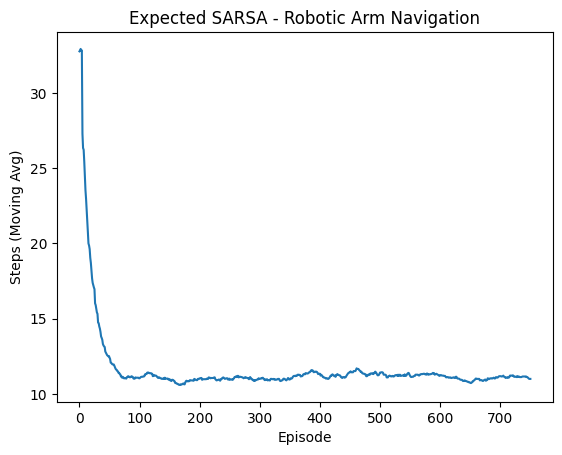

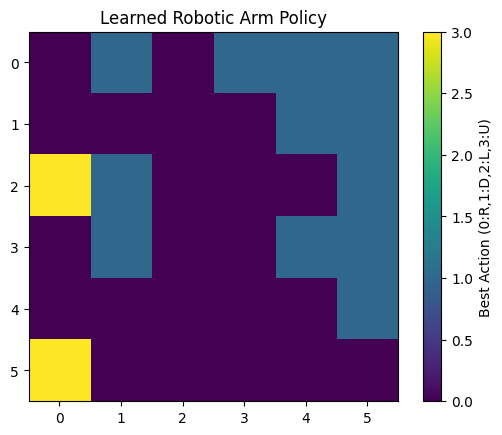

Training Complete!


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Robotic Arm Workspace Environment
# =====================================
class RoboticArmGrid:
    def __init__(self, width=6, height=6,
                 start=(0,0), goal=(5,5),
                 obstacles=[(2,2),(3,2),(2,3)]):

        self.width = width
        self.height = height
        self.start = start
        self.goal = goal
        self.obstacles = obstacles

        # Right, Down, Left, Up
        self.actions = [(0,1),(1,0),(0,-1),(-1,0)]
        self.reset()

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        x, y = self.state
        dx, dy = self.actions[action]

        new_x = np.clip(x + dx, 0, self.width-1)
        new_y = np.clip(y + dy, 0, self.height-1)

        # obstacle handling
        if (new_x, new_y) in self.obstacles:
            new_x, new_y = x, y

        self.state = (new_x, new_y)

        if self.state == self.goal:
            reward = 100   # successful pick
            done = True
        else:
            reward = -1    # movement cost
            done = False

        return self.state, reward, done

# =====================================
# Expected SARSA Agent
# =====================================
class ExpectedSARSA:
    def __init__(self, env, alpha=0.1, gamma=0.95, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        self.q_table = np.zeros((env.width, env.height, len(env.actions)))

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(len(self.env.actions))
        else:
            x, y = state
            return np.argmax(self.q_table[x, y])

    def expected_q(self, next_state):
        x, y = next_state
        q_vals = self.q_table[x, y]
        greedy = np.argmax(q_vals)

        expected = 0
        nA = len(self.env.actions)

        for a in range(nA):
            if a == greedy:
                prob = 1 - self.epsilon + self.epsilon/nA
            else:
                prob = self.epsilon/nA
            expected += prob * q_vals[a]

        return expected

    def update(self, state, action, reward, next_state, done):
        x, y = state
        current_q = self.q_table[x, y, action]

        if done:
            target = reward
        else:
            target = reward + self.gamma * self.expected_q(next_state)

        self.q_table[x, y, action] += self.alpha * (target - current_q)

# =====================================
# Training Function
# =====================================
def train(env, agent, episodes=800):
    episode_lengths = []

    for ep in range(episodes):
        state = env.reset()
        done = False
        steps = 0

        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state, done)

            state = next_state
            steps += 1

        episode_lengths.append(steps)

    return episode_lengths

# =====================================
# Policy Visualization
# =====================================
def plot_policy(env, agent):
    policy_grid = np.zeros((env.width, env.height))

    for x in range(env.width):
        for y in range(env.height):
            if (x,y) not in env.obstacles:
                policy_grid[x,y] = np.argmax(agent.q_table[x,y])

    plt.imshow(policy_grid, cmap='viridis')
    plt.colorbar(label="Best Action (0:R,1:D,2:L,3:U)")
    plt.title("Learned Robotic Arm Policy")
    plt.show()

# =====================================
# Run Simulation
# =====================================
env = RoboticArmGrid()
agent = ExpectedSARSA(env)

episode_lengths = train(env, agent, episodes=800)

# Plot learning curve
plt.plot(np.convolve(episode_lengths, np.ones(50)/50, mode='valid'))
plt.xlabel("Episode")
plt.ylabel("Steps (Moving Avg)")
plt.title("Expected SARSA - Robotic Arm Navigation")
plt.show()

# Visualize learned policy
plot_policy(env, agent)

print("Training Complete!")

In [7]:
print("\nLearned Q-values per state:\n")

for x in range(env.width):
    for y in range(env.height):
        if (x, y) in env.obstacles:
            print(f"State ({x},{y}) : Obstacle")
        else:
            q_vals = agent.q_table[x, y]
            print(f"State ({x},{y}) : {np.round(q_vals, 2)}")

# Global average Q-value
global_avg_q = np.mean(agent.q_table)

print("Global Average Q-value:", round(global_avg_q, 4))


Learned Q-values per state:

State (0,0) : [39.99 17.62 23.37 22.59]
State (0,1) : [12.17 44.86 26.81 32.19]
State (0,2) : [38.64  2.04 -2.08 -2.08]
State (0,3) : [-1.53 54.88 -1.5   6.96]
State (0,4) : [-1.1  46.42  3.01  2.68]
State (0,5) : [-0.78  3.96 -0.87 -0.79]
State (1,0) : [39.94 -1.75 -0.48  0.15]
State (1,1) : [51.13 -1.16 19.57 27.  ]
State (1,2) : [57.12 36.58 33.73 16.57]
State (1,3) : [62.9  50.52 37.62 36.1 ]
State (1,4) : [36.14 69.98 47.35 21.19]
State (1,5) : [-0.5  69.44 -0.51 -0.64]
State (2,0) : [-2.31 -2.32 -2.36  7.31]
State (2,1) : [-2.09  3.11 -2.21 -2.06]
State (2,2) : Obstacle
State (2,3) : Obstacle
State (2,4) : [76.73 46.91 60.69 45.59]
State (2,5) : [61.93 84.36 60.18 32.58]
State (3,0) : [-1.72 -1.72 -1.72 -1.85]
State (3,1) : [-1.55 12.31 -1.48 -1.56]
State (3,2) : Obstacle
State (3,3) : [ 4.22 -0.19 -0.2  -0.1 ]
State (3,4) : [-0.1  76.93 -0.25 11.52]
State (3,5) : [69.86 92.14 50.85 67.5 ]
State (4,0) : [ 1.28 -1.22 -1.27 -1.25]
State (4,1) : [28.11 

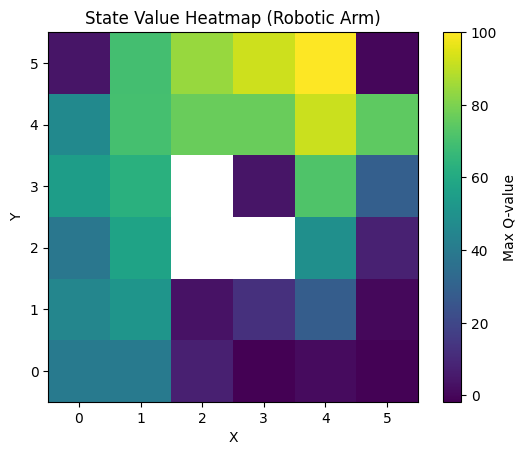

In [5]:
import matplotlib.pyplot as plt

max_q_grid = np.zeros((env.width, env.height))

for x in range(env.width):
    for y in range(env.height):
        if (x,y) not in env.obstacles:
            max_q_grid[x,y] = np.max(agent.q_table[x,y])
        else:
            max_q_grid[x,y] = np.nan

plt.imshow(max_q_grid.T, origin='lower')
plt.colorbar(label="Max Q-value")
plt.title("State Value Heatmap (Robotic Arm)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [6]:
action_symbols = {
    0: "→",   # Right
    1: "↓",   # Down
    2: "←",   # Left
    3: "↑"    # Up
}

policy_grid = np.empty((env.width, env.height), dtype=object)

for x in range(env.width):
    for y in range(env.height):
        if (x,y) in env.obstacles:
            policy_grid[x,y] = "X"
        elif (x,y) == env.goal:
            policy_grid[x,y] = "G"
        else:
            best_action = np.argmax(agent.q_table[x,y])
            policy_grid[x,y] = action_symbols[best_action]

print("\nLearned Policy (Robotic Arm Movement):\n")
for y in reversed(range(env.height)):
    for x in range(env.width):
        print(policy_grid[x,y], end="  ")
    print()


Learned Policy (Robotic Arm Movement):

↓  ↓  ↓  ↓  ↓  G  
↓  ↓  →  ↓  →  →  
↓  →  X  →  →  →  
→  →  X  X  →  →  
↓  →  ↓  ↓  →  →  
→  →  ↑  →  →  ↑  
